# Importing the Required Modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Implementing the DecisionTreeRegressor from the scratch

In [2]:
class DecisionTreeRegressor:
    """
    Decision Tree Regressor implemented from scratch using CART methodology.
    Splitting criterion: Mean Squared Error (MSE).
    """

    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    
    # Building the tree recursively
    def _build_tree(self, X, y, depth=0):
        X, y = np.array(X), np.array(y)

        # Stopping conditions → leaf node
        if len(y) <= self.min_samples_split or depth >= self.max_depth:
            return {"value": np.mean(y)}

        n_samples, n_features = X.shape
        best_feature, best_threshold = None, None
        best_loss = float("inf")

        for feature in range(n_features):
            values = np.unique(X[:, feature])
            thresholds = (values[:-1] + values[1:]) / 2  # midpoint strategy

            for threshold in thresholds:
                left_mask = X[:, feature] < threshold
                right_mask = ~left_mask

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                y_left, y_right = y[left_mask], y[right_mask]

                loss = (
                    np.sum((y_left - np.mean(y_left)) ** 2)
                    + np.sum((y_right - np.mean(y_right)) ** 2)
                )

                if loss < best_loss:
                    best_loss = loss
                    best_feature = feature
                    best_threshold = threshold

        if best_feature is None:
            return {"value": np.mean(y)}

        return {
            "feature": best_feature,
            "threshold": best_threshold,
            "left": self._build_tree(
                X[X[:, best_feature] < best_threshold],
                y[X[:, best_feature] < best_threshold],
                depth + 1
            ),
            "right": self._build_tree(
                X[X[:, best_feature] >= best_threshold],
                y[X[:, best_feature] >= best_threshold],
                depth + 1
            )
        }

    def fit(self, X, y):
        self.tree = self._build_tree(X, y)

    def _predict_one(self, x, node):
        if "value" in node:
            return node["value"]
        if x[node["feature"]] < node["threshold"]:
            return self._predict_one(x, node["left"])
        else:
            return self._predict_one(x, node["right"])

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

    # Printing the Tree Structure
    def print_tree(self, node=None, depth=0):
        if node is None:
            node = self.tree
        indent = "│   " * depth

        if "value" in node:
            print(f"{indent}└── Leaf → Predict = {node['value']:.2f}")
            return

        print(f"{indent}└── Feature[{node['feature']}] < {node['threshold']:.2f}")
        self.print_tree(node["left"], depth + 1)
        self.print_tree(node["right"], depth + 1)


# Training the tree and testing it

In [3]:
X_train = np.array([[1, 2],[2, 3],[3, 4],[4, 5],[5, 6],[6, 7],[7, 8],[8, 9]])
y_train = np.array([3, 5, 7, 9, 11, 13, 15, 17])

X_test = np.array([[1.5, 2.5],[3.5, 4.5],[5.5, 6.5],[7.5, 8.5]])
y_test = np.array([4, 8, 12, 16])

In [4]:
model = DecisionTreeRegressor(max_depth=3, min_samples_split=2)
model.fit(X_train, y_train)

print("Decision Tree Structure:\n")
model.print_tree()

Decision Tree Structure:

└── Feature[0] < 4.50
│   └── Feature[0] < 2.50
│   │   └── Leaf → Predict = 4.00
│   │   └── Leaf → Predict = 8.00
│   └── Feature[0] < 6.50
│   │   └── Leaf → Predict = 12.00
│   │   └── Leaf → Predict = 16.00


In [5]:
y_pred = model.predict(X_test)

mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)
r2 = 1 - np.sum((y_test - y_pred) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2)

print("\nEvaluation Metrics:")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


Evaluation Metrics:
MSE  : 0.0000
RMSE : 0.0000
R²   : 1.0000


# Let us come up with some useful visualizations

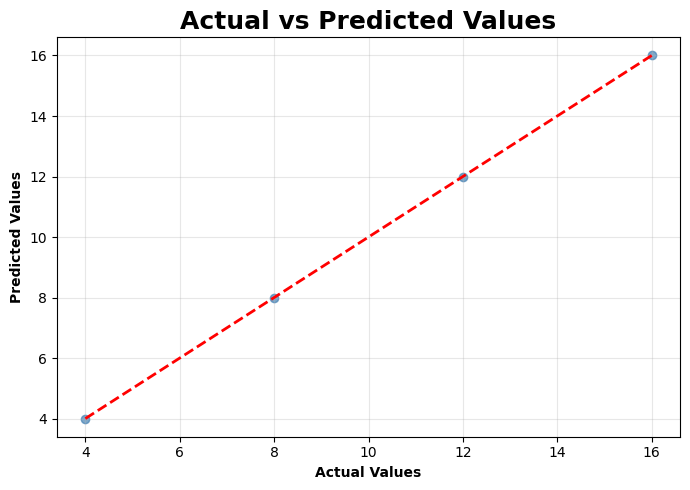

In [6]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.xlabel("Actual Values",fontweight='bold')
plt.ylabel("Predicted Values",fontweight='bold')
plt.title("Actual vs Predicted Values",fontweight='bold',fontsize=18)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

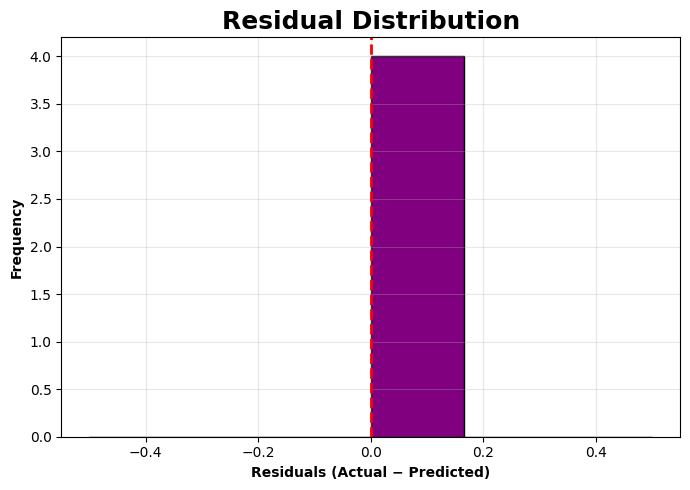

In [7]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.hist(residuals, bins=6, color='purple', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)

plt.xlabel("Residuals (Actual − Predicted)",fontweight='bold')
plt.ylabel("Frequency",fontweight='bold')
plt.title("Residual Distribution",fontweight='bold',fontsize=18)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


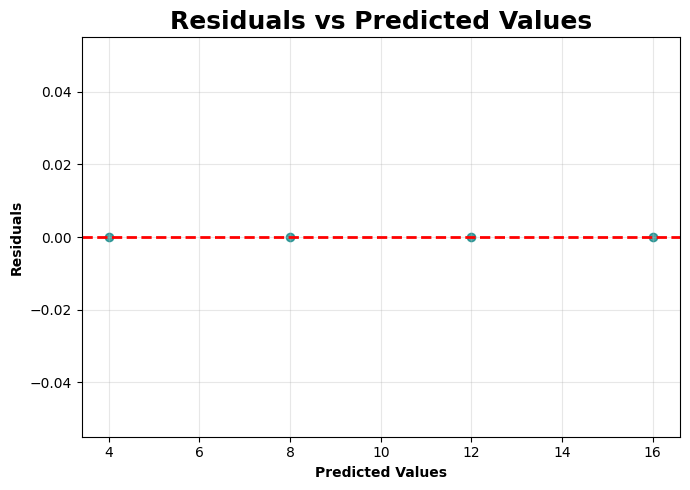

In [8]:
plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, color='teal', alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=2)

plt.xlabel("Predicted Values",fontweight='bold')
plt.ylabel("Residuals",fontweight='bold')
plt.title("Residuals vs Predicted Values",fontweight='bold',fontsize=18)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

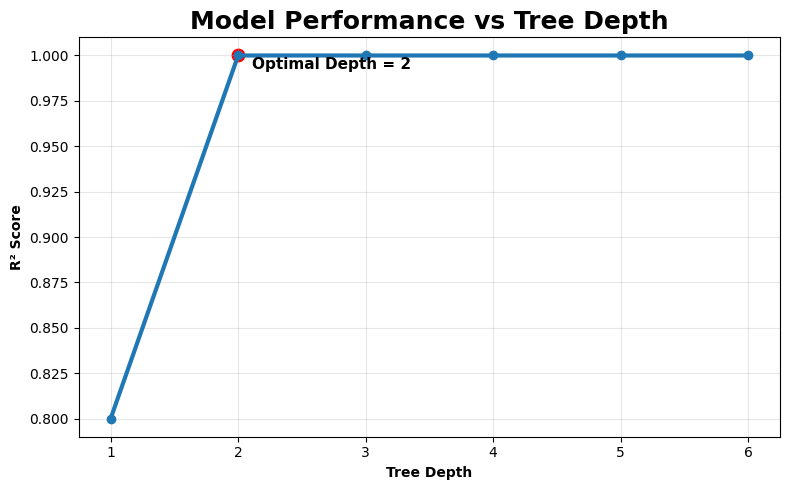

In [9]:
depths = range(1, 7)
r2_scores = []

for d in depths:
    temp_model = DecisionTreeRegressor(max_depth=d, min_samples_split=2)
    temp_model.fit(X_train, y_train)
    temp_pred = temp_model.predict(X_test)
    r2_temp = 1 - np.sum((y_test - temp_pred) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2)
    r2_scores.append(r2_temp)

plt.figure(figsize=(8,5))
plt.plot(depths, r2_scores, marker='o', linewidth=3)

best_depth = depths[np.argmax(r2_scores)]
best_r2 = max(r2_scores)

plt.scatter(best_depth, best_r2, color='red', s=80)
plt.annotate(f"Optimal Depth = {best_depth}",
             (best_depth, best_r2),
             textcoords="offset points",
             xytext=(10,-10),
             fontsize=11,
             fontweight='bold')

plt.xlabel("Tree Depth",fontweight='bold')
plt.ylabel("R² Score",fontweight='bold')
plt.title("Model Performance vs Tree Depth",fontweight='bold',fontsize=18)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


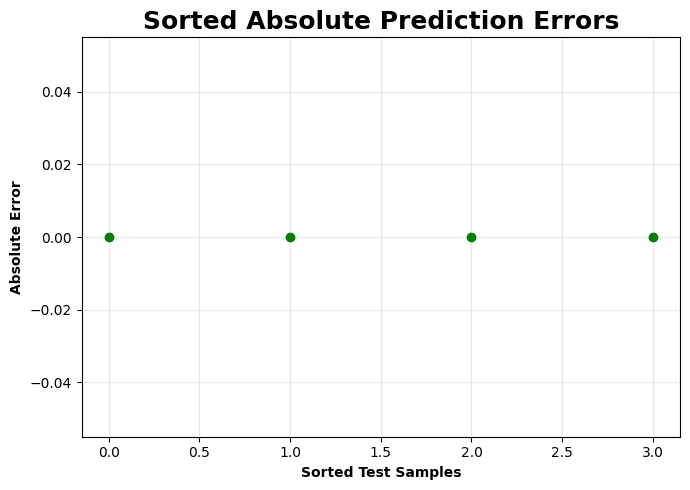

In [10]:
abs_errors = np.abs(residuals)
sorted_errors = np.sort(abs_errors)

plt.figure(figsize=(7,5))
plt.stem(range(len(sorted_errors)), sorted_errors,
         basefmt=" ", linefmt="green", markerfmt="go")

plt.xlabel("Sorted Test Samples",fontweight='bold')
plt.ylabel("Absolute Error",fontweight='bold')
plt.title("Sorted Absolute Prediction Errors",fontweight='bold',fontsize=18)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Note: Since a synthetic, deterministic dataset is used for demonstration, 
# the model achieves a perfect fit. This is intentional and helps validate 
# the correctness of the from-scratch implementation.


# Thank You